In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [57]:
df = pd.read_csv("insurance.csv")

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [58]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [59]:

print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


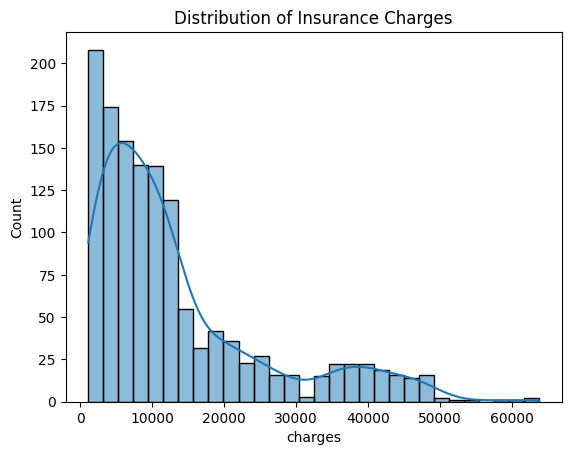

In [ ]:
#Data Visualization
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

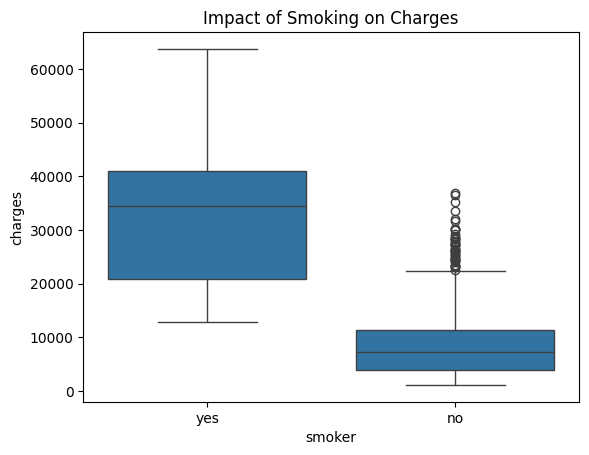

In [61]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Impact of Smoking on Charges")
plt.show()

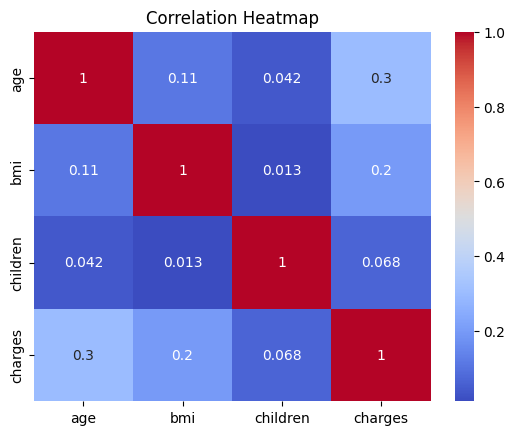

In [62]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Encode Categorical Data
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
#Feature and Target Separation
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Model Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))

In [ ]:
#Linear Regression Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

evaluate_model("Linear Regression", y_test, y_pred_lr)


Linear Regression Results
RMSE: 5796.284659276275
MAE: 4181.194473753654
R2 Score: 0.7835929767120722


In [ ]:
#Random Forest Model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest Results
RMSE: 4576.299916157115
MAE: 2550.0784706115096
R2 Score: 0.8651034329144947


In [ ]:
#Gradient Boosting Model
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

evaluate_model("Gradient Boosting", y_test, y_pred_gb)


Gradient Boosting Results
RMSE: 4329.570010504765
MAE: 2443.483262376879
R2 Score: 0.8792571359795264


In [ ]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.783593
1      Random Forest  0.865103
2  Gradient Boosting  0.879257


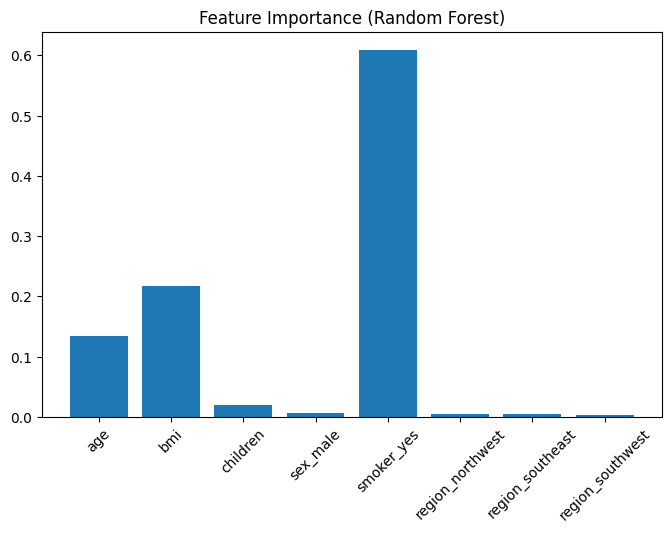

In [ ]:
#Feature Importance
importance = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.show()